# Machine Learning

## Imports

1. Have an expert
2. Expert system (have an expert, codify their knowledge)
3. Machine learning (have a collection of data, build rules)

Types of machine learning:

1. Supervised - labeled data (here is what it should look like)

2. Unsupervised - unlabeled data (find patterns)

In [35]:
import pandas as pd
import altair as alt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import ConfusionMatrixDisplay, precision_score
import matplotlib.pyplot as plt

## Data Sourcing

In [2]:
penguins = pd.read_csv(
    "https://sigma-resources-public.s3.eu-west-2.amazonaws.com/datasets/penguins.csv")

In [3]:
penguins.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


## Data Cleaning

(Dan has done it)

In [4]:
penguins.isna().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

## Data Exploration

Longest flipper length.

In [5]:
penguins["flipper_length_mm"].max()

np.float64(231.0)

Most common island

In [6]:
penguins["island"].mode()

0    Biscoe
Name: island, dtype: object

Comparison of sex.

In [7]:
penguins["sex"].value_counts()

sex
MALE      168
FEMALE    165
Name: count, dtype: int64

In [8]:
alt.Chart(penguins).mark_point().encode(
    x = alt.X("flipper_length_mm").scale(zero=False),
    y = alt.Y("body_mass_g").scale(zero=False),
    color = 'species',
    shape = 'sex'
)

alt.Chart(...)

In [9]:
alt.Chart(penguins["island"].value_counts().reset_index()).mark_bar().encode(
    x = "island",
    y = "count"
)

alt.Chart(...)

In [10]:
alt.Chart(penguins).mark_boxplot().encode(
    x ="culmen_length_mm",
    y = "species",
    tooltip=["species", 
             "island", 
             "culmen_length_mm", 
             "culmen_depth_mm", 
             "flipper_length_mm", 
             "body_mass_g", 
             "sex"]
)

alt.Chart(...)

## Preprocess


In [70]:
X = penguins
X

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
329,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
330,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
331,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [92]:
# X = penguins[["culmen_length_mm", "culmen_depth_mm"]] # The predictors/the data to trina on/the information the model is allowed
X = penguins[["culmen_depth_mm", "culmen_length_mm",
               "flipper_length_mm"]]
# X = pd.get_dummies(X)  # Replace all categorical columns with binary ones
y = penguins["species"] # The target/label/class - the thing we want to know

In [100]:
X = penguins.drop(['species'], axis=1)
X = pd.get_dummies(X)
X

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,False,False,True,False,True
1,39.5,17.4,186.0,3800.0,False,False,True,True,False
2,40.3,18.0,195.0,3250.0,False,False,True,True,False
3,36.7,19.3,193.0,3450.0,False,False,True,True,False
4,39.3,20.6,190.0,3650.0,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...
328,47.2,13.7,214.0,4925.0,True,False,False,True,False
329,46.8,14.3,215.0,4850.0,True,False,False,True,False
330,50.4,15.7,222.0,5750.0,True,False,False,False,True
331,45.2,14.8,212.0,5200.0,True,False,False,True,False


In [93]:
# Split into test/train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=451)

## Model

In [94]:
model = DecisionTreeClassifier(max_depth=4, random_state=451) # Thing that can learn

In [95]:
model.fit(X_train, y_train) # Train the model

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,451
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [81]:
# model.predict([(49.9, 16.1)])

In [96]:
model.score(X_test, y_test)

0.9701492537313433

In [97]:
y_pred = model.predict(X_test)

In [84]:
y_pred

array(['Adelie', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo', 'Chinstrap',
       'Chinstrap', 'Chinstrap', 'Adelie', 'Gentoo', 'Gentoo', 'Adelie',
       'Gentoo', 'Adelie', 'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo',
       'Chinstrap', 'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo', 'Gentoo',
       'Adelie', 'Adelie', 'Adelie', 'Chinstrap', 'Adelie', 'Adelie',
       'Adelie', 'Gentoo', 'Adelie', 'Gentoo', 'Gentoo', 'Adelie',
       'Gentoo', 'Gentoo', 'Adelie', 'Chinstrap', 'Chinstrap',
       'Chinstrap', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Chinstrap',
       'Gentoo', 'Chinstrap', 'Adelie', 'Adelie', 'Gentoo', 'Adelie',
       'Gentoo', 'Chinstrap', 'Adelie', 'Gentoo', 'Adelie', 'Chinstrap',
       'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie', 'Chinstrap', 'Adelie',
       'Chinstrap', 'Chinstrap'], dtype=object)

In [98]:
precision_score(y_test, y_pred, average="macro")

0.9666666666666667

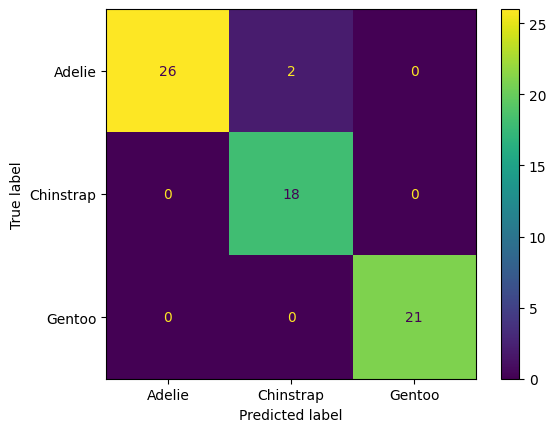

In [99]:
ConfusionMatrixDisplay.from_estimator(model, X=X_test, y=y_test)

''

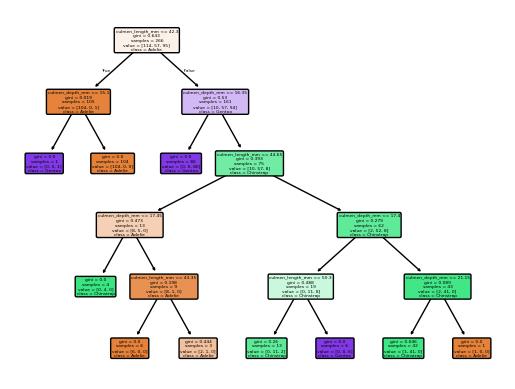

In [57]:
plt.Figure(figsize=(20,30))
plot_tree(decision_tree=model, 
          feature_names=X_train.columns, 
          class_names=model.classes_,
          rounded=True,
          filled=True)
plt.savefig("tree.png", dpi=1000)
;


## Evaluate